# Notebook ML — Boosting : AdaBoost, XGBoost, LightGBM
**Paire 3 | AML×ADL 2025–2026 | Master 1 IA — Université de Nouakchott**

**Fil conducteur :** Le boosting séquentiel (chaque apprenant corrige le précédent)
est analogue à la connexion résiduelle de ResNet (y = F(x) + x).

In [4]:
# ============================================================
# 0. SETUP & SEEDS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, random, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('✅ Seeds fixés — SEED =', SEED)

✅ Seeds fixés — SEED = 42


## 1. AdaBoost From Scratch (NumPy)
> Point 6 — Implémentation minimale exigée par §3.4

In [5]:
# ============================================================
# 1.1 Stump de décision (apprenant faible)
# ============================================================
class DecisionStump:
    """Classificateur faible : seuil sur une feature."""
    def __init__(self):
        self.feature_idx = None
        self.threshold   = None
        self.polarity    = 1
        self.alpha       = None  # poids dans l'ensemble

    def fit(self, X, y, weights):
        n_samples, n_features = X.shape
        min_error = float('inf')

        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for thr in thresholds:
                for polarity in [1, -1]:
                    preds = np.where(polarity * X[:, feat] < polarity * thr, -1, 1)
                    error = np.sum(weights[preds != y])
                    if error < min_error:
                        min_error          = error
                        self.polarity      = polarity
                        self.threshold     = thr
                        self.feature_idx   = feat
        return min_error

    def predict(self, X):
        return np.where(
            self.polarity * X[:, self.feature_idx] < self.polarity * self.threshold,
            -1, 1
        )

In [6]:
# ============================================================
# 1.2 AdaBoost
# Formule : alpha_t = 0.5 * ln((1-eps_t)/eps_t)
#           w(t+1,i) ∝ w(t,i) * exp(-alpha_t * y_i * h_t(x_i))
# ============================================================
class AdaBoostScratch:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []

    def fit(self, X, y):
        """y doit être en {-1, +1}"""
        n = len(y)
        weights = np.ones(n) / n  # initialisation uniforme
        self.stumps = []

        for t in range(self.n_estimators):
            stump = DecisionStump()
            eps_t = stump.fit(X, y, weights)

            # Sortie anticipée si erreur >= 0.5
            if eps_t >= 0.5:
                break

            # alpha_t : poids de ce classificateur
            eps_t = max(eps_t, 1e-10)  # éviter log(0)
            alpha_t = 0.5 * np.log((1 - eps_t) / eps_t)
            stump.alpha = alpha_t

            # Mise à jour des poids
            preds = stump.predict(X)
            weights *= np.exp(-alpha_t * y * preds)
            weights /= np.sum(weights)  # normalisation

            self.stumps.append(stump)

        return self

    def predict(self, X):
        clf_preds = np.array([s.alpha * s.predict(X) for s in self.stumps])
        return np.sign(clf_preds.sum(axis=0)).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [7]:
# ============================================================
# 1.3 Test sur données synthétiques
# ============================================================
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier

X, y = make_classification(n_samples=500, n_features=10, random_state=SEED)
y_pm = np.where(y == 0, -1, 1)  # conversion {0,1} → {-1,+1}

X_tr, X_te, y_tr, y_te = train_test_split(X, y_pm, test_size=0.2, random_state=SEED)

# From scratch
ada_scratch = AdaBoostScratch(n_estimators=50).fit(X_tr, y_tr)
acc_scratch = ada_scratch.score(X_te, y_te)

# sklearn (référence)
ada_sk = AdaBoostClassifier(n_estimators=50, random_state=SEED)
ada_sk.fit(X_tr, np.where(y_tr==-1,0,1))
acc_sk = ada_sk.score(X_te, np.where(y_te==-1,0,1))

print(f'AdaBoost From Scratch : {acc_scratch:.4f}')
print(f'AdaBoost sklearn      : {acc_sk:.4f}')

AdaBoost From Scratch : 0.8900
AdaBoost sklearn      : 0.9000


## 2. Benchmark Empirique — Adult Income
> Point 7 — Étude expérimentale sur ≥ 2 datasets

In [8]:
# ============================================================
# 2.1 Chargement Adult Income (UCI via sklearn)
# ============================================================
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder

print('Chargement Adult Income...')
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
df = adult.frame.dropna()

# Encodage des catégorielles
X_adult = df.drop('class', axis=1).copy()
y_adult = (df['class'].str.strip() == '>50K').astype(int)

for col in X_adult.select_dtypes('category').columns:
    X_adult[col] = LabelEncoder().fit_transform(X_adult[col].astype(str))

X_adult = X_adult.astype(float).values
y_adult = y_adult.values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=SEED, stratify=y_adult
)
print(f'Train : {X_tr2.shape} | Test : {X_te2.shape}')
print(f'Classe 1 (>50K) : {y_adult.mean():.1%}')

Chargement Adult Income...
Train : (36177, 14) | Test : (9045, 14)
Classe 1 (>50K) : 24.8%


In [9]:
# ============================================================
# 2.2 Benchmark : sklearn GB vs XGBoost vs LightGBM
# ============================================================
!pip install xgboost
!pip install lightgbm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

models = {
    'sklearn GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost':   XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM':  LGBMClassifier(n_estimators=200, random_state=SEED, verbose=-1),
}

results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr2, y_tr2)
    t_train = time.time() - t0

    preds = model.predict(X_te2)
    proba = model.predict_proba(X_te2)[:, 1]

    results.append({
        'Modèle':   name,
        'F1-macro': round(f1_score(y_te2, preds, average='macro'), 4),
        'AUC-ROC':  round(roc_auc_score(y_te2, proba), 4),
        'Temps (s)': round(t_train, 2)
    })

df_bench = pd.DataFrame(results)
print(df_bench.to_string(index=False))

                  Modèle  F1-macro  AUC-ROC  Temps (s)
sklearn GradientBoosting    0.8044   0.9228      13.51
                 XGBoost    0.8075   0.9212       2.25
                LightGBM    0.8124   0.9260       0.97


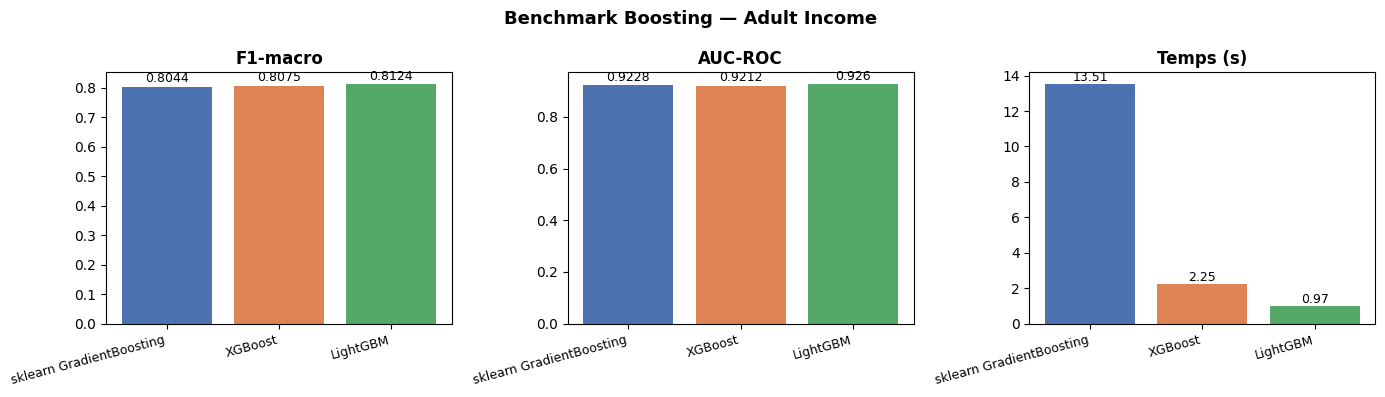

In [10]:
# ============================================================
# 2.3 Visualisation benchmark
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, ['F1-macro', 'AUC-ROC', 'Temps (s)']):
    bars = ax.bar(df_bench['Modèle'], df_bench[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(len(df_bench)))
    ax.set_xticklabels(df_bench['Modèle'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, df_bench[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Benchmark Boosting — Adult Income', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_boosting.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tuning Bayésien avec Optuna

In [11]:
# ============================================================
# 3.1 Optuna — XGBoost sur Adult Income
# ============================================================
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'random_state':  SEED,
        'eval_metric':   'logloss',
        'verbosity':     0,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_tr2, y_tr2, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Meilleur AUC-ROC (CV) : {study.best_value:.4f}')
print('Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.0 MB/s eta 0:00:00


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleur AUC-ROC (CV) : 0.9280
Meilleurs hyperparamètres :
  n_estimators: 434
  max_depth: 4
  learning_rate: 0.09521594049584939
  subsample: 0.99734345048353
  colsample_bytree: 0.5430084694121357
  reg_alpha: 0.9139378382927937


In [12]:
# ============================================================
# 3.2 Visualisation Optuna
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score

# Entraînement final avec les meilleurs params
best_xgb = XGBClassifier(**study.best_params, random_state=SEED, eval_metric='logloss', verbosity=0)
best_xgb.fit(X_tr2, y_tr2)
preds_best = best_xgb.predict(X_te2)
proba_best = best_xgb.predict_proba(X_te2)[:, 1]
print(f'\nXGBoost Optimisé — F1: {f1_score(y_te2, preds_best, average="macro"):.4f} | AUC: {roc_auc_score(y_te2, proba_best):.4f}')


XGBoost Optimisé — F1: 0.8117 | AUC: 0.9277


## 4. Analyse SHAP — Interprétabilité

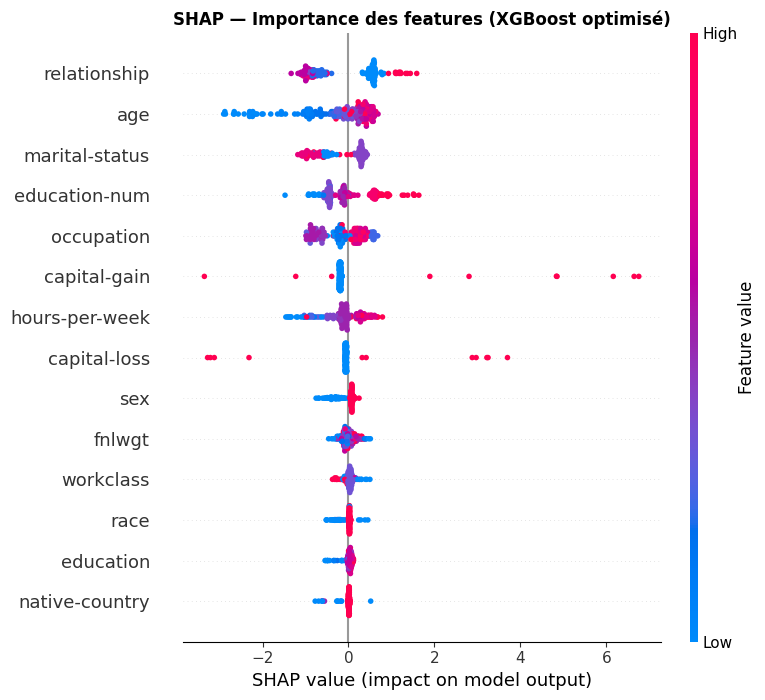

In [13]:
# ============================================================
# 4.1 SHAP Summary Plot
# ============================================================
!pip install shap
import shap

feature_names = adult.feature_names
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_te2[:200])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_te2[:200], feature_names=feature_names, show=False)
plt.title('SHAP — Importance des features (XGBoost optimisé)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Lien Boosting ↔ ResNet (Point 8 §3.4)

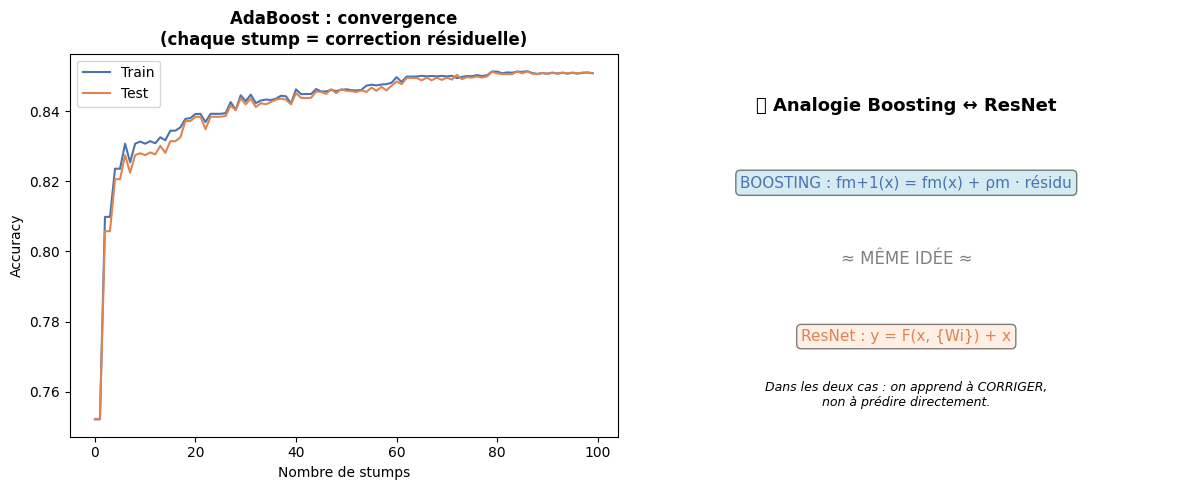


✅ Notebook ML Boosting — TERMINÉ
Figures générées : benchmark_boosting.png | optuna_results.png | shap_summary.png | analogie_boosting_resnet.png


In [14]:
# ============================================================
# 5. Visualisation analogie Boosting ↔ ResNet
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Courbe convergence AdaBoost
ada_sk2 = AdaBoostClassifier(n_estimators=100, random_state=SEED)
ada_sk2.fit(X_tr2, y_tr2)
errors_train = list(ada_sk2.staged_score(X_tr2, y_tr2))
errors_test  = list(ada_sk2.staged_score(X_te2, y_te2))

axes[0].plot(errors_train, label='Train', color='#4C72B0')
axes[0].plot(errors_test,  label='Test',  color='#DD8452')
axes[0].set_xlabel('Nombre de stumps')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('AdaBoost : convergence\n(chaque stump = correction résiduelle)', fontweight='bold')
axes[0].legend()

# Schéma conceptuel
axes[1].axis('off')
axes[1].text(0.5, 0.85, '🔁 Analogie Boosting ↔ ResNet', ha='center', fontsize=13, fontweight='bold')
axes[1].text(0.5, 0.65, 'BOOSTING : fm+1(x) = fm(x) + ρm · résidu', ha='center', fontsize=11, color='#4C72B0',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].text(0.5, 0.45, '≈ MÊME IDÉE ≈', ha='center', fontsize=12, color='gray')
axes[1].text(0.5, 0.25, 'ResNet : y = F(x, {Wi}) + x', ha='center', fontsize=11, color='#DD8452',
             bbox=dict(boxstyle='round', facecolor='#FFE0CC', alpha=0.5))
axes[1].text(0.5, 0.08, 'Dans les deux cas : on apprend à CORRIGER,\nnon à prédire directement.',
             ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('analogie_boosting_resnet.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Notebook ML Boosting — TERMINÉ')
print('Figures générées : benchmark_boosting.png | optuna_results.png | shap_summary.png | analogie_boosting_resnet.png')